In [1]:
%pip install -q sysidentpy numpy scipy torch scikit-learn

import time
import os
from pathlib import Path

import scipy.io as sio
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from itertools import combinations_with_replacement
from sysidentpy.neural_network import NARXNN
from sysidentpy.basis_function import Polynomial
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('mps' if torch.backends.mps.is_available() else ('cuda' if torch.cuda.is_available() else 'cpu'))
print(f"Device in uso: {device}")

try:
    # Collega Google Drive (colab fallback supportato da VS Code)
    from google.colab import drive
    drive.mount('/content/drive')
    
    # IMPORTANTE: Modifica questo percorso col path del tuo file su google drive!
    # Puoi caricare manualmente la cartella Benchmark_EEG_small nel tuo Drive.
    data_path = Path('/content/drive/MyDrive/Benchmark_EEG_small/Benchmark_EEG_small.mat')
    
except ImportError:
    # Fallback per l'esecuzione in locale
    data_path = Path('./Benchmark_EEG_small/Benchmark_EEG_small.mat')

data = sio.loadmat(data_path)
u_3d = data['data']['u'].item()  # shape: (10, 7, 256)
y_3d = data['data']['y'].item()  # EEG output

u_trials = u_3d.reshape(-1, 256)
y_trials = y_3d.reshape(-1, 256)

n_trials = u_trials.shape[0]
trial_len = u_trials.shape[1]
print(f"Loaded dataset with {u_trials.size} samples")

You should consider upgrading via the '/Applications/Xcode.app/Contents/Developer/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
Device in uso: mps
Loaded dataset with 17920 samples


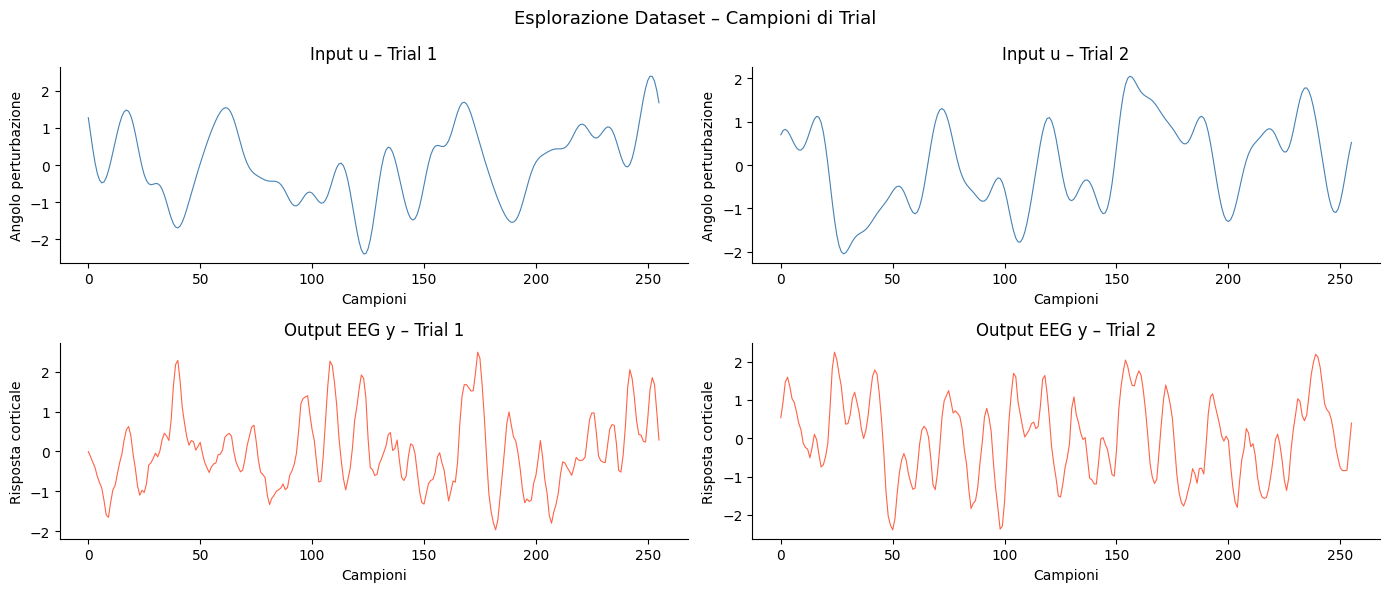

u – media: 0.0000  std: 0.9999  range: [-2.724, 2.724]
y – media: -0.0000  std: 0.9857  range: [-3.716, 3.809]


In [2]:
fig, axes = plt.subplots(2, 2, figsize=(14, 6))
fig.suptitle("Esplorazione Dataset – Campioni di Trial", fontsize=13)

for i, ax in enumerate(axes[0]):
    ax.plot(u_trials[i], color='steelblue', lw=0.8)
    ax.set_title(f"Input u – Trial {i+1}")
    ax.set_xlabel("Campioni")
    ax.set_ylabel("Angolo perturbazione")

for i, ax in enumerate(axes[1]):
    ax.plot(y_trials[i], color='tomato', lw=0.8)
    ax.set_title(f"Output EEG y – Trial {i+1}")
    ax.set_xlabel("Campioni")
    ax.set_ylabel("Risposta corticale")

plt.tight_layout()
plt.savefig("data_exploration.png", dpi=120)
plt.show()

# Statistiche di base
print(f"u – media: {u_trials.mean():.4f}  std: {u_trials.std():.4f}  range: [{u_trials.min():.3f}, {u_trials.max():.3f}]")
print(f"y – media: {y_trials.mean():.4f}  std: {y_trials.std():.4f}  range: [{y_trials.min():.3f}, {y_trials.max():.3f}]")


In [3]:
# Split 70/15/15% per trial interi – nessun data leakage temporale
n_train = int(np.floor(0.70 * n_trials))
n_val   = int(np.floor(0.15 * n_trials))
n_test  = n_trials - n_train - n_val

idx = np.random.permutation(n_trials)
train_idx = idx[:n_train]
val_idx   = idx[n_train:n_train + n_val]
test_idx  = idx[n_train + n_val:]

u_train_trials = u_trials[train_idx]  # (n_train, 256)
y_train_trials = y_trials[train_idx]
u_val_trials   = u_trials[val_idx]
y_val_trials   = y_trials[val_idx]
u_test_trials  = u_trials[test_idx]
y_test_trials  = y_trials[test_idx]

# Appiattimento del training per il fit (SysIdentPy vuole (N,1))
u_train_flat = u_train_trials.reshape(-1, 1)
y_train_flat = y_train_trials.reshape(-1, 1)

print(f"Train : {n_train} trial ({n_train * trial_len} campioni)")
print(f"Val   : {n_val}   trial ({n_val  * trial_len} campioni)")
print(f"Test  : {n_test}  trial ({n_test * trial_len} campioni)")

Train : 49 trial (12544 campioni)
Val   : 10   trial (2560 campioni)
Test  : 11  trial (2816 campioni)


In [4]:
scaler_u = StandardScaler()
scaler_y = StandardScaler()

u_train_s = scaler_u.fit_transform(u_train_flat)
y_train_s = scaler_y.fit_transform(y_train_flat)

def scale_trials(scaler, trials_2d):
    flat_s = scaler.transform(trials_2d.reshape(-1, 1))
    return flat_s.reshape(trials_2d.shape)

u_val_trials_s  = scale_trials(scaler_u, u_val_trials)
y_val_trials_s  = scale_trials(scaler_y, y_val_trials)
u_test_trials_s = scale_trials(scaler_u, u_test_trials)
y_test_trials_s = scale_trials(scaler_y, y_test_trials)
utrain_trials_s = scale_trials(scaler_u, u_train_trials)  # shape (49, 256)
ytrain_trials_s = scale_trials(scaler_y, y_train_trials)  # shape (49, 256)

print("Normalizzazione completata")

Normalizzazione completata


In [5]:
NY = 10
NU = 10
DEGREE = 1
H1, H2, H3 = 64, 32, 32
EPOCHS = 500
LEARNING_RATE = 1e-3  # was 1e-5 — too small for Adam; 1e-3 converges much faster
BATCH_SIZE = 128
INPUT_SIZE = NY + NU

class NARXResNet(nn.Module):
    def __init__(self, input_size, hidden=64):
        super().__init__()
        self.input_proj = nn.Linear(input_size, hidden)
        self.res1 = nn.Sequential(
            nn.Linear(hidden, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden))
        self.res2 = nn.Sequential(
            nn.Linear(hidden, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden))
        self.out = nn.Linear(hidden, 1)
        self.act = nn.Tanh()

    def forward(self, x):
        h = self.act(self.input_proj(x))
        h = self.act(h + self.res1(h))   # residual block 1
        h = self.act(h + self.res2(h))   # residual block 2
        return self.out(h)

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

net = NARXResNet(INPUT_SIZE, hidden=H1).to(device)
print(net)
print(f"Parametri: {count_params(net):,}")

NARXResNet(
  (input_proj): Linear(in_features=20, out_features=64, bias=True)
  (res1): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=64, bias=True)
  )
  (res2): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=64, bias=True)
  )
  (out): Linear(in_features=64, out_features=1, bias=True)
  (act): Tanh()
)
Parametri: 18,049


In [6]:
# Cella 3: Inizializzazione modello
input_size = NY + NU
# Inizializziamo il modello su cpu perché SysIdentPy invia i tensori su cpu
net = NARXResNet(input_size=input_size, hidden=H1).to('cpu')

model = NARXNN(
    net=net,
    ylag=NY,
    xlag=NU,
    basis_function=Polynomial(degree=DEGREE),
    loss_func='mse_loss',
    optimizer='Adam',
    optim_params={},
    epochs=EPOCHS,
    learning_rate=LEARNING_RATE,
    batch_size=BATCH_SIZE,
    device='cpu',  # SysIdentPy non accetta "mps" nativamente
    verbose=False,
)

print(f"NARX input size: {input_size}")

NARX input size: 20


In [7]:
print("Training NARX...")
t0 = time.perf_counter()
model.fit(X=u_train_s, y=y_train_s)
train_time_s = time.perf_counter() - t0
print(f"Training completed in {train_time_s:.2f} s")


Training NARX...
Training completed in 35.21 s


In [8]:
def predict_per_trial(model, u_trials_s, y_trials_s, steps_ahead=None):
    preds_list = []
    for i in range(len(u_trials_s)):
        u_t = u_trials_s[i].reshape(-1, 1)
        y_t = y_trials_s[i].reshape(-1, 1)
        yhat_t = model.predict(X=u_t, y=y_t, steps_ahead=steps_ahead)
        preds_list.append(np.asarray(yhat_t).ravel())
    return preds_list

def evaluate_per_trial(preds_list, y_trials_s, scaler_y):
    vafs, nrmses, rmses = [], [], []
    for i, yhat_s in enumerate(preds_list):
        y_true_s = y_trials_s[i].ravel()
        n = len(yhat_s)
        y_true_s = y_true_s[-n:]
        y_true = scaler_y.inverse_transform(y_true_s.reshape(-1, 1)).ravel()
        y_pred = scaler_y.inverse_transform(yhat_s.reshape(-1, 1)).ravel()
        var_true = np.var(y_true)
        if var_true > 0:
            vafs.append((1 - np.var(y_true - y_pred) / var_true) * 100.0)
        rmse_v = np.sqrt(mean_squared_error(y_true, y_pred))
        rmses.append(rmse_v)
        denom = np.max(y_true) - np.min(y_true)
        if denom > 0:
            nrmses.append(rmse_v / denom)
    return {
        'VAF (%)': np.mean(vafs),
        'NRMSE': np.mean(nrmses),
        'RMSE': np.mean(rmses),
    }

val_1step_preds = predict_per_trial(model, u_val_trials_s, y_val_trials_s, steps_ahead=1)
val_free_preds  = predict_per_trial(model, u_val_trials_s, y_val_trials_s, steps_ahead=None)
test_1step_preds = predict_per_trial(model, u_test_trials_s, y_test_trials_s, steps_ahead=1)
test_free_preds  = predict_per_trial(model, u_test_trials_s, y_test_trials_s, steps_ahead=None)

res_val_1step  = evaluate_per_trial(val_1step_preds,  y_val_trials_s,  scaler_y)
res_val_free   = evaluate_per_trial(val_free_preds,   y_val_trials_s,  scaler_y)
res_test_1step = evaluate_per_trial(test_1step_preds, y_test_trials_s, scaler_y)
res_test_free  = evaluate_per_trial(test_free_preds,  y_test_trials_s, scaler_y)

print('\nRISULTATI MODELLO STANDARD')
for name, r in [
    ('val 1-step', res_val_1step),
    ('val free-run', res_val_free),
    ('test 1-step', res_test_1step),
    ('test free-run', res_test_free),
]:
    print(f"[{name}] VAF={r['VAF (%)']:.2f}% NRMSE={r['NRMSE']:.4f} RMSE={r['RMSE']:.5f}")


RISULTATI MODELLO STANDARD
[val 1-step] VAF=91.34% NRMSE=0.0572 RMSE=0.28673
[val free-run] VAF=-165.07% NRMSE=0.3366 RMSE=1.66569
[test 1-step] VAF=89.78% NRMSE=0.0605 RMSE=0.29824
[test free-run] VAF=-164.26% NRMSE=0.3330 RMSE=1.63330


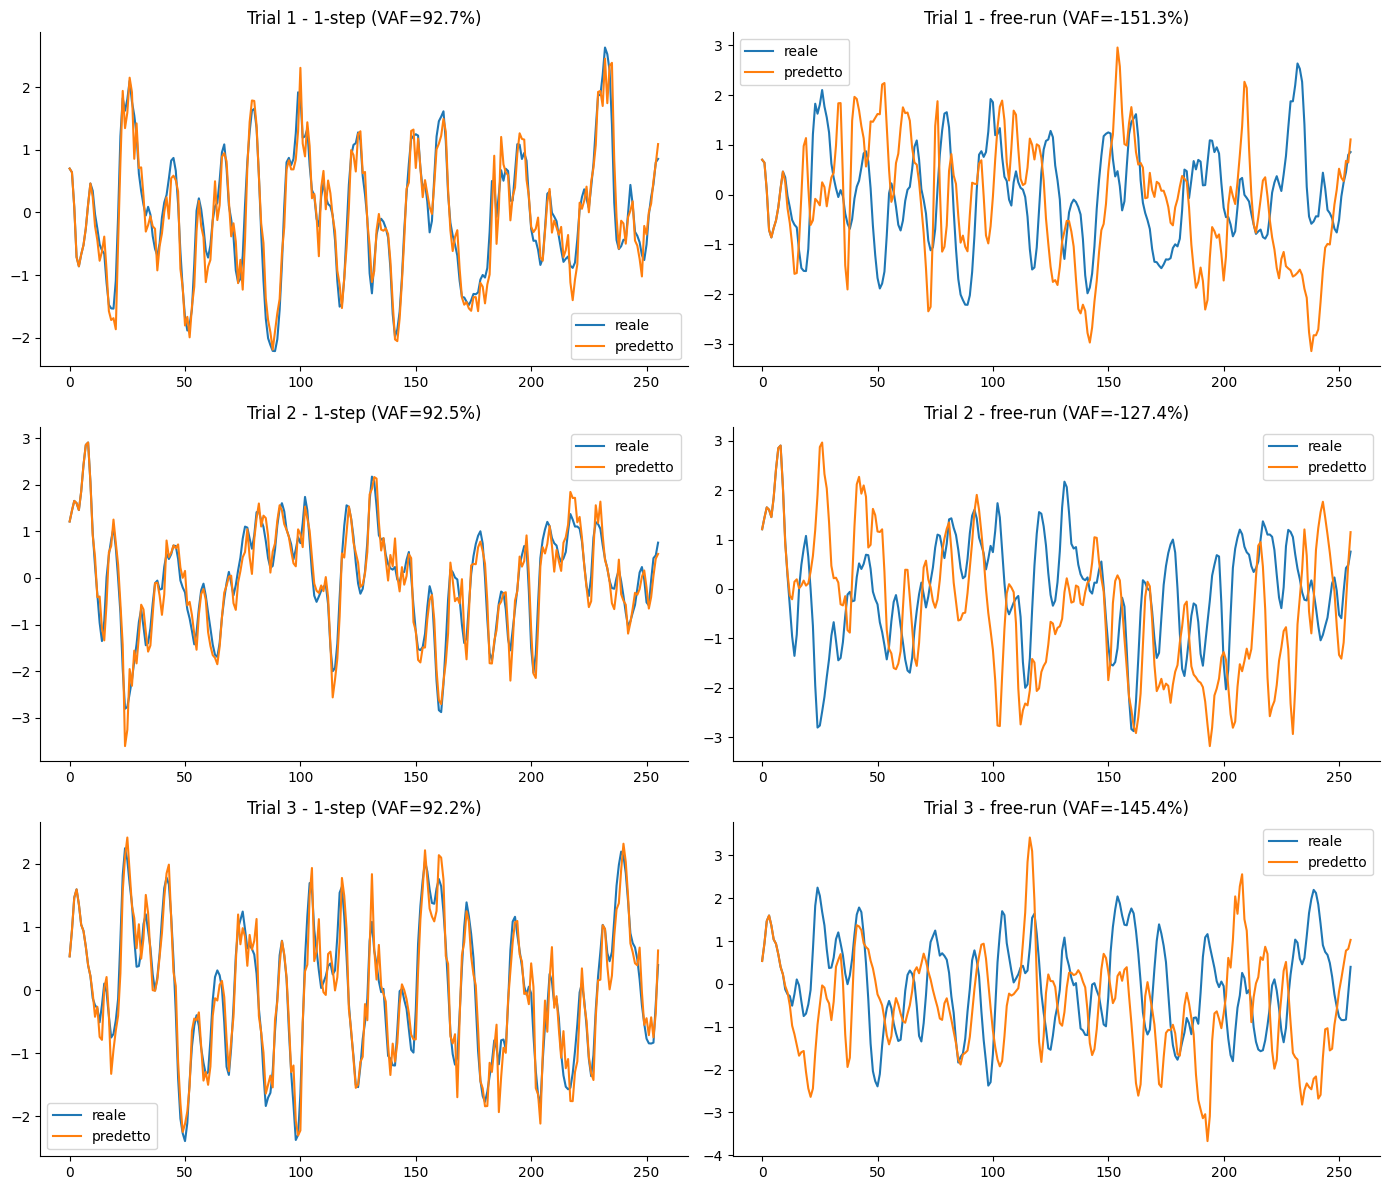

In [9]:
n_show = min(3, len(test_free_preds))
fig, axes = plt.subplots(n_show, 2, figsize=(14, 4 * n_show))
if n_show == 1:
    axes = axes[np.newaxis, :]

for i in range(n_show):
    for j, (preds, label) in enumerate([(test_1step_preds, '1-step'), (test_free_preds, 'free-run')]):
        yhat_s = preds[i]
        y_true_s = y_test_trials_s[i].ravel()[-len(yhat_s):]
        y_true = scaler_y.inverse_transform(y_true_s.reshape(-1, 1)).ravel()
        y_pred = scaler_y.inverse_transform(yhat_s.reshape(-1, 1)).ravel()
        vaf_v = (1 - np.var(y_true - y_pred) / np.var(y_true)) * 100
        axes[i, j].plot(y_true, label='reale')
        axes[i, j].plot(y_pred, label='predetto')
        axes[i, j].set_title(f'Trial {i+1} - {label} (VAF={vaf_v:.1f}%)')
        axes[i, j].legend()
plt.tight_layout()
plt.show()

In [12]:
import torch.optim as optim        

def build_regressor_at_t(y_buf, u_seq, t, NY, NU):
    y_lags = [y_buf[t - k] for k in range(1, NY + 1)]
    u_lags = [u_seq[t - k] for k in range(1, NU + 1)]
    return y_lags + u_lags


def train_scheduled_sampling(net, us_trials, ys_trials, NY, NU,
                              epochs=500, lr=1e-4, batch_size=128,
                              ss_start=0.0, ss_end=0.8):
    net = net.to(device)          # fix: ensure model is on same device as tensors
    optimizer = optim.Adam(net.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=20
    )
    criterion = nn.MSELoss()
    maxlag = max(NY, NU)
    n_trials = len(us_trials)
    loss_history = []

    for epoch in range(epochs):
        p_free = ss_start + (ss_end - ss_start) * epoch / max(epochs - 1, 1)
        Xall_ep, Yall_ep = [], []

        for i in range(n_trials):          # ← per-trial loop
            unp = us_trials[i].ravel().tolist()
            ybuf = ys_trials[i].ravel().tolist()
            y_np = ys_trials[i].ravel()
            T = len(unp)

            net.eval()
            with torch.no_grad():
                for t in range(maxlag, T):
                    if np.random.random() < p_free:
                        # free-run: use model's own previous output
                        reg = torch.tensor(
                            build_regressor_at_t(ybuf, unp, t, NY, NU),
                            dtype=torch.float32).to(device)
                        ybuf[t] = net(reg).item()
                    else:
                        # teacher-forced: restore ground-truth so lags are accurate
                        ybuf[t] = y_np[t]
    
            Xall_ep += [build_regressor_at_t(ybuf, unp, t, NY, NU)
                        for t in range(maxlag, T)]
            Yall_ep += [y_np[t] for t in range(maxlag, T)]

        Xall = torch.tensor(Xall_ep, dtype=torch.float32).to(device)
        Yall = torch.tensor(Yall_ep, dtype=torch.float32).unsqueeze(1).to(device)

        net.train()
        perm = torch.randperm(len(Xall))
        ep_loss, nb = 0.0, 0
        for start in range(0, len(Xall), batch_size):
            ib = perm[start:start + batch_size]
            optimizer.zero_grad()
            loss = criterion(net(Xall[ib]), Yall[ib])
            loss.backward()
            torch.nn.utils.clip_grad_norm_(net.parameters(), 0.5)  # ← fix 2
            optimizer.step()
            ep_loss += loss.item(); nb += 1

        avg_loss = ep_loss / max(nb, 1)
        scheduler.step(avg_loss)    # reduce LR on plateau
        loss_history.append(avg_loss)

    return net, loss_history

def predict_free_run_manual(net, u_trial_s, y_trial_s, NY, NU):
    net = net.to(device)
    net.eval()
    T = len(u_trial_s)
    max_lag = max(NY, NU)
    y_buf = y_trial_s.ravel().tolist()
    u_seq = u_trial_s.ravel().tolist()
    preds = []
    with torch.no_grad():
        for t in range(max_lag, T):
            reg = torch.tensor([build_regressor_at_t(y_buf, u_seq, t, NY, NU)], dtype=torch.float32).to(device)
            yhat = net(reg).item()
            y_buf[t] = yhat
            preds.append(yhat)
    return np.array(preds, dtype=np.float32)

In [ ]:
torch.manual_seed(SEED)
np.random.seed(SEED)
net_ss = NARXResNet(INPUT_SIZE, H1)  # fix: NARXNet was undefined, correct name is NARXResNet

print('Training con Scheduled Sampling...')
t0 = time.perf_counter()
net_ss, ss_loss = train_scheduled_sampling(
    net_ss, utrain_trials_s, ytrain_trials_s,  # fix: was flat u_train_s/y_train_s — SS needs per-trial arrays
    NY=NY, NU=NU,
    epochs=300,
    lr=LEARNING_RATE,
    batch_size=BATCH_SIZE,
    ss_start=0.0,
    ss_end=0.8,
)
print(f"Training SS completato in {time.perf_counter() - t0:.1f} s")

Training con Scheduled Sampling...
Training SS completato in 151.7 s



RISULTATI SCHEDULED SAMPLING
Val  -> VAF=4.02% NRMSE=0.1906
Test -> VAF=0.23% NRMSE=0.1907


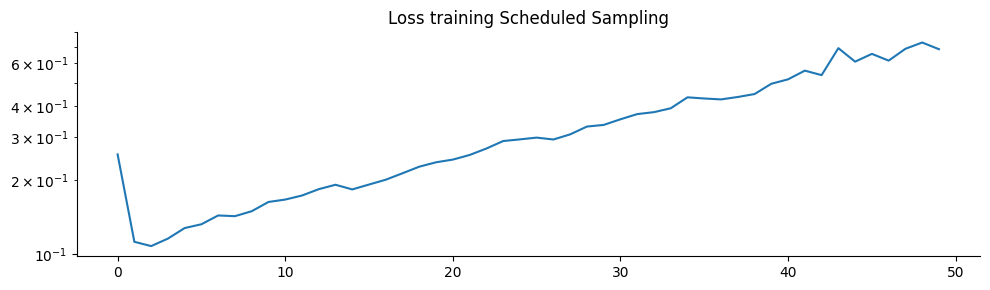

In [16]:
def eval_ss_model(net_ss, u_trials_s, y_trials_s, scaler_y, NY, NU):
    vafs, nrmses = [], []
    for i in range(len(u_trials_s)):
        yhat_s = predict_free_run_manual(net_ss, u_trials_s[i], y_trials_s[i], NY, NU)
        n = len(yhat_s)
        y_true_s = y_trials_s[i].ravel()[-n:]
        y_true = scaler_y.inverse_transform(y_true_s.reshape(-1, 1)).ravel()
        y_pred = scaler_y.inverse_transform(yhat_s.reshape(-1, 1)).ravel()
        vt = np.var(y_true)
        if vt > 0:
            vafs.append((1 - np.var(y_true - y_pred) / vt) * 100)
        denom = np.max(y_true) - np.min(y_true)
        if denom > 0:
            nrmses.append(np.sqrt(np.mean((y_true - y_pred) ** 2)) / denom)
    return np.mean(vafs), np.mean(nrmses)

vaf_val, nrmse_val = eval_ss_model(net_ss, u_val_trials_s, y_val_trials_s, scaler_y, NY, NU)
vaf_test, nrmse_test = eval_ss_model(net_ss, u_test_trials_s, y_test_trials_s, scaler_y, NY, NU)

print('\nRISULTATI SCHEDULED SAMPLING')
print(f"Val  -> VAF={vaf_val:.2f}% NRMSE={nrmse_val:.4f}")
print(f"Test -> VAF={vaf_test:.2f}% NRMSE={nrmse_test:.4f}")

plt.figure(figsize=(10, 3))
plt.plot(ss_loss)
plt.yscale('log')
plt.title('Loss training Scheduled Sampling')
plt.tight_layout()
plt.show()

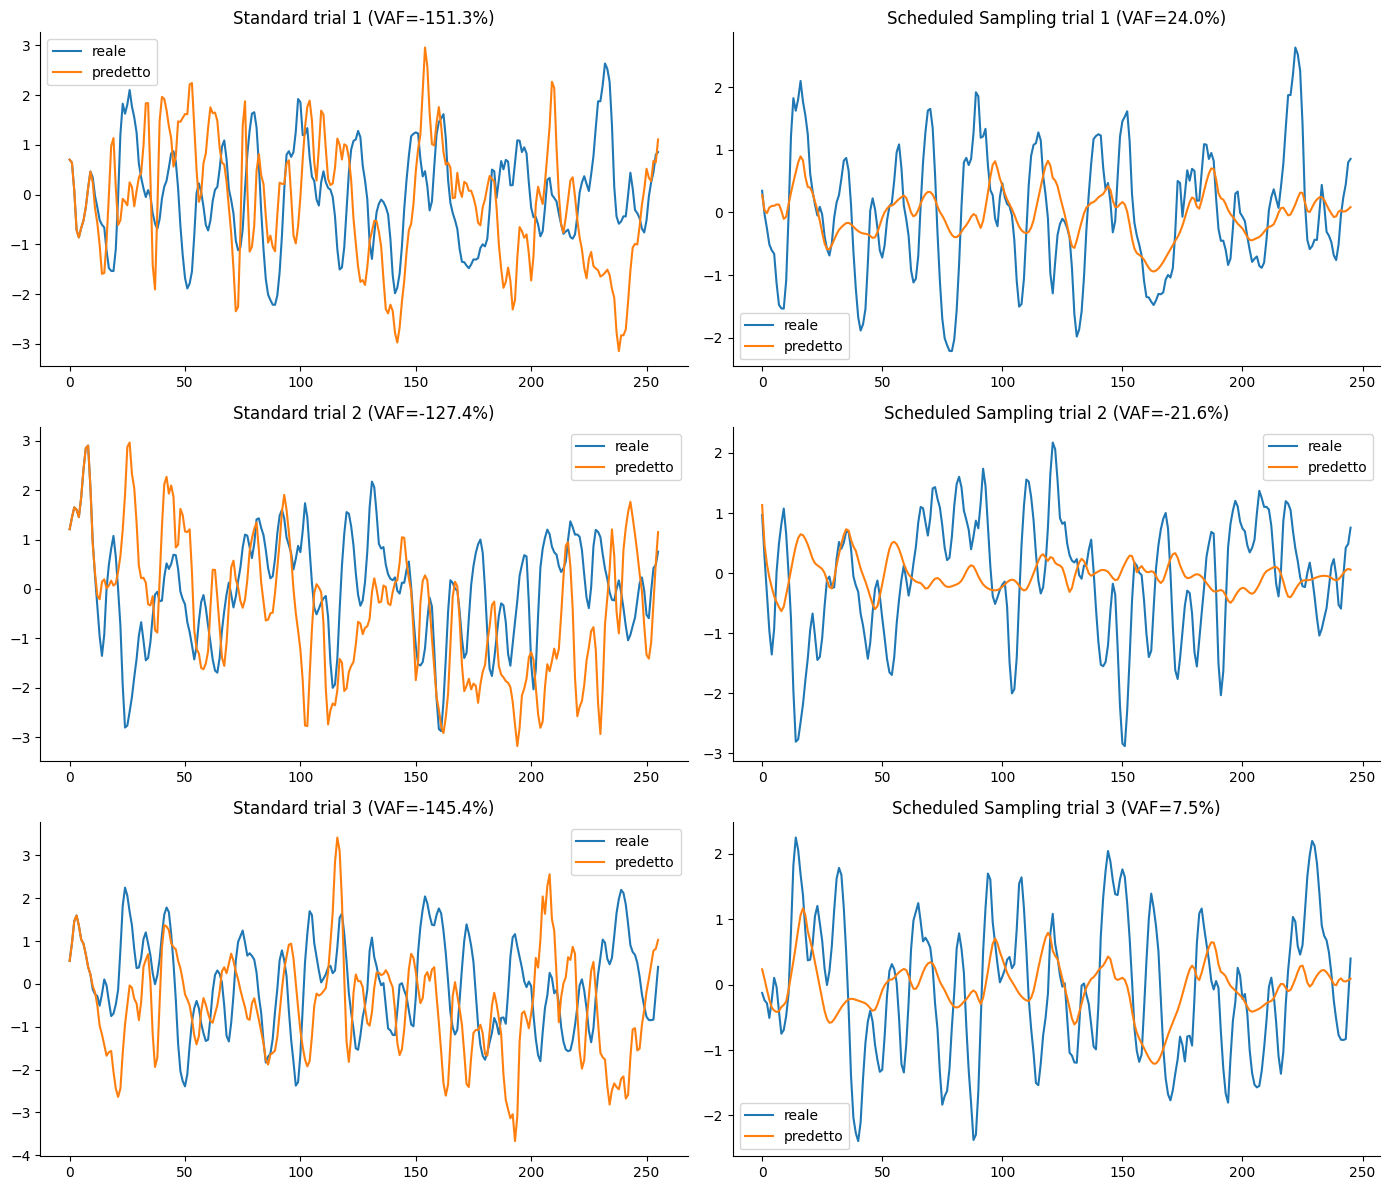

In [17]:
n_show = min(3, len(u_test_trials_s))
fig, axes = plt.subplots(n_show, 2, figsize=(14, 4 * n_show))
if n_show == 1:
    axes = axes[np.newaxis, :]

for i in range(n_show):
    yhat_std_s = test_free_preds[i]
    yt_s = y_test_trials_s[i].ravel()[-len(yhat_std_s):]
    yt_std = scaler_y.inverse_transform(yt_s.reshape(-1, 1)).ravel()
    yp_std = scaler_y.inverse_transform(yhat_std_s.reshape(-1, 1)).ravel()
    vaf_std = (1 - np.var(yt_std - yp_std) / np.var(yt_std)) * 100

    yhat_ss_s = predict_free_run_manual(net_ss, u_test_trials_s[i], y_test_trials_s[i], NY, NU)
    yt_s2 = y_test_trials_s[i].ravel()[-len(yhat_ss_s):]
    yt_ss = scaler_y.inverse_transform(yt_s2.reshape(-1, 1)).ravel()
    yp_ss = scaler_y.inverse_transform(yhat_ss_s.reshape(-1, 1)).ravel()
    vaf_ss = (1 - np.var(yt_ss - yp_ss) / np.var(yt_ss)) * 100

    axes[i, 0].plot(yt_std, label='reale')
    axes[i, 0].plot(yp_std, label='predetto')
    axes[i, 0].set_title(f'Standard trial {i+1} (VAF={vaf_std:.1f}%)')
    axes[i, 0].legend()

    axes[i, 1].plot(yt_ss, label='reale')
    axes[i, 1].plot(yp_ss, label='predetto')
    axes[i, 1].set_title(f'Scheduled Sampling trial {i+1} (VAF={vaf_ss:.1f}%)')
    axes[i, 1].legend()

plt.tight_layout()
plt.show()